# **PyTorch Tutorial for Dataset/Dataloader**
This tutorial notebook aims at getting you familiar with Dataset and Dataloader in PyTorch. It contains:

> 1. How to upload mnist dataset
> 2. What is a PyTorch Dataset and how to setup a PyTorch Dataset
> 3. Load mnist data into your defined PyTorch Dataset
> 4. Understand the relation between PyTorch Dataset and Dataloader
> 5. Understand the concept of *batch* and *batch size*

In [ ]:
"""
Step 1: import crucial packages
"""
import torch
from torch.utils.data import Dataset, DataLoader
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from PIL import Image

In [ ]:
"""
Step 2: upload the dataset source file from your local PC.
"""
from google.colab import files
# Upload the file
%rm -rf mnist_test.csv
uploaded = files.upload()

Saving mnist_test.csv to mnist_test.csv


In [ ]:
"""
Step 3: define the dataset
Recall the content in Lesson 12
that the build-in __getitem__ function allows us to read one or a few data samples instead of the entire dataset
"""
class CSVDataset(Dataset):
    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.num_samples = self._get_num_samples()
        self.indexes = list(range(self.num_samples))

    def _get_num_samples(self):
        with open(self.csv_path, 'r') as file:
            info = file.readlines()
        return len(info)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        line_number = self.indexes[index]
        with open(self.csv_path, 'r') as file:
            reader = csv.reader(file)
            for _ in range(line_number+1):
                line = next(reader)
            data = torch.tensor([int(i) for i in line], dtype=torch.float32)
            feat = data[1:]/255.0
            label = data[0]
            return feat, label

In [ ]:
"""
Step 4: initialize your mnist dataset and feel free to visit its contents
"""
dataset = CSVDataset('mnist_test.csv')
print(dataset.num_samples)

train_size = int(0.9*len(dataset))
print(train_size)

val_size = len(dataset) - train_size

print(val_size)

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

2000
1800
200
tensor([3., 1., 0., 5., 1., 7., 1., 8.])
tensor([4., 7., 0., 5., 3., 5., 7., 5.])
tensor([2., 9., 2., 8., 7., 1., 0., 4.])


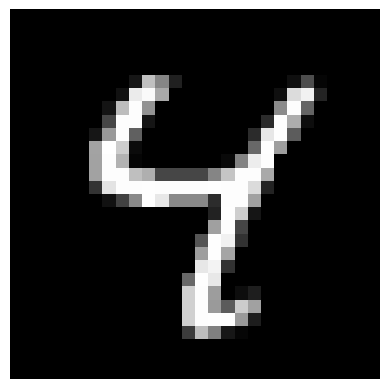

The label of this mnist sample is: 4.0


In [ ]:
"""
Step 5: try to visualize your loaded mnist data!
"""
def visualize_one_sample(dataset, index):
    sample_image = np.array(dataset[index][0]).reshape(28, 28)  # Convert to NumPy array
    sample_image = np.uint8(sample_image * 255.0)

    plt.imshow(sample_image, cmap = "gray")
    plt.axis('off')
    plt.show()

    # after visualizing the image, print the corresponding label
    print(f"The label of this mnist sample is: {dataset[index][1].item()}")

# feel free to use this function to see what data you are exactly loading!
visualize_one_sample(dataset, 6)

In [ ]:
"""
Step 6: After getting familiar with PyTorch Dataset, let us move on to PyTorch Dataloader
"""
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle=False) # when shuffle is false, recall the first label printed by the dataloader and that in dataset[0]

for i, data in enumerate(train_loader):
    # You can directly use for loop to load the data
    inputs, labels = data
    print(labels)
    if i == 1:
        break

tensor([5., 6., 9., 0., 1., 5., 2., 4.])
tensor([7., 6., 4., 1., 5., 7., 3., 5.])
